In [1]:
import os
import glob
from PIL import Image
import torch
import torchvision.transforms as T
from torch_geometric.data import Dataset
from torch_geometric.transforms import ToSLIC, KNNGraph
from torch_geometric.loader import DataLoader

class WingSuperpixelDataset(Dataset):
    def __init__(self, root_dir):
        super().__init__()
        self.root_dir = root_dir
        
        # Find all images inside subdirectories (expects folders named after classes)
        self.image_paths = sorted(
            glob.glob(os.path.join(root_dir, "*", "*.png")) +
            glob.glob(os.path.join(root_dir, "*", "*.jpg")) +
            glob.glob(os.path.join(root_dir, "*", "*.JPG"))
        )
        
        # Automatically map folder names to integer class labels
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        # PyG Transforms: ToSLIC creates superpixel nodes, KNNGraph connects neighboring nodes
        self.slic_transform = ToSLIC(n_segments=150, add_img=False)
        self.knn_transform = KNNGraph(k=6) # Connects each superpixel to its 6 nearest spatial neighbors

    def len(self):
        return len(self.image_paths)

    def get(self, idx):
        img_path = self.image_paths[idx]
        
        # Extract class label from the parent folder name
        class_name = os.path.basename(os.path.dirname(img_path))
        label = self.class_to_idx[class_name]
        
        # 1. Load raw image and convert to RGB tensor format [Channels, Height, Width]
        image = Image.open(img_path).convert('RGB')
        img_tensor = T.ToTensor()(image)
        
        # 2. Convert raw pixels into a Superpixel Graph object
        data = self.slic_transform(img_tensor)
        data = self.knn_transform(data)
        
        # 3. Attach the target classification label
        data.y = torch.tensor([label], dtype=torch.long)
        
        return data

# --- How to Run and Test the Dataset ---
if __name__ == "__main__":
    # Point this to your main folder containing subfolders of classes
    dataset_path = "C:/Users/User/bee's wings classification/wings_geo" 
    
    if not os.path.exists(dataset_path):
        print(f"Please create a directory named '{dataset_path}' with class subfolders.")
    else:
        dataset = WingSuperpixelDataset(root_dir=dataset_path)
        print(f"Total graphs loaded: {len(dataset)}")
        print(f"Classes found: {dataset.class_to_idx}")
        
        # Test loading a single sample graph
        if len(dataset) > 0:
            sample_graph = dataset[0]
            print("\nSample Graph Structure:")
            print(sample_graph)
            print(f"Node feature matrix shape (x): {sample_graph.x.shape}")
            print(f"Node spatial coordinates shape (pos): {sample_graph.pos.shape}")
            print(f"Edge index shape (connectivity): {sample_graph.edge_index.shape}")
            print(f"Target label (y): {sample_graph.y}")
            
            # Create a PyG DataLoader for batching graphs during training
            loader = DataLoader(dataset, batch_size=16, shuffle=True)
            for batch in loader:
                print("\nBatch Structure for GNN training:")
                print(batch)
                break

C:\Users\User\anaconda3\envs\beesenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\User\anaconda3\envs\beesenv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Total graphs loaded: 2144
Classes found: {'Agapostemon_sericeus': 0, 'Agapostemon_texanus': 1, 'Bombus_bimaculatus': 2, 'Bombus_griseocolis': 3, 'Bombus_impatiens': 4, 'Bombus_perplexus': 5, 'Bombus_sandersonii': 6, 'Bombus_vagans': 7, 'Ceratina_calcarata': 8, 'Lasioglossum_acuminatum': 9, 'Lasioglossum_admirandum': 10, 'Lasioglossum_coriaceum': 11, 'Lasioglossum_leucozonium': 12, 'Lasioglossum_nymphaerum': 13, 'Lasioglossum_pilosum': 14, 'Lasioglossum_rohweri': 15, 'Lasioglossum_zephyrum': 16, 'Lasioglossum_zonulum': 17}

Sample Graph Structure:
Data(x=[92, 3], pos=[92, 2], edge_index=[2, 552], y=[1])
Node feature matrix shape (x): torch.Size([92, 3])
Node spatial coordinates shape (pos): torch.Size([92, 2])
Edge index shape (connectivity): torch.Size([2, 552])
Target label (y): tensor([0])

Batch Structure for GNN training:
DataBatch(x=[1796, 3], pos=[1796, 2], edge_index=[2, 10776], y=[16], batch=[1796], ptr=[17])


Visualizing superpixels for: C:\Users\User\bee's wings classification\wings_geo\Agapostemon_sericeus\836 Agapostemon sericeus f left 3.2x.jpg


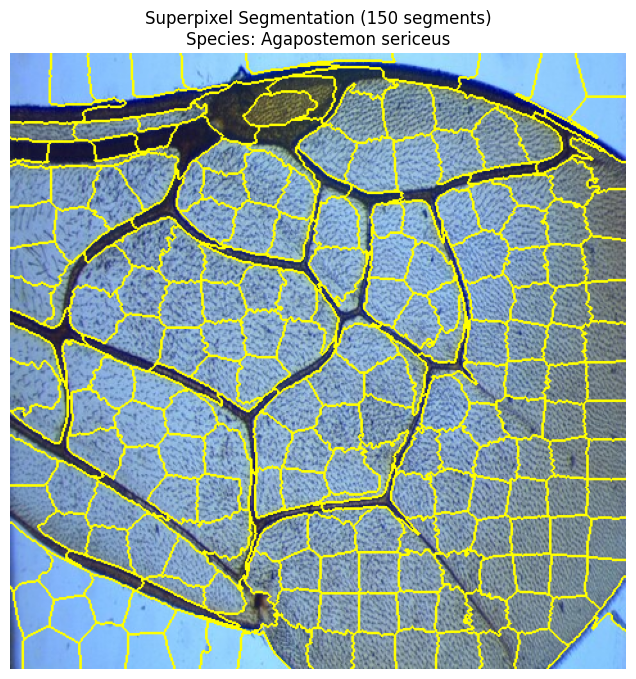

In [3]:
import matplotlib.pyplot as plt
from skimage.segmentation import slic, mark_boundaries
from PIL import Image
import numpy as np

# 1. Define your exact dataset root path
dataset_path = r"C:\Users\User\bee's wings classification\wings_geo"

# 2. Point directly to that specific image file using your folder structure
sample_img_path = r"C:\Users\User\bee's wings classification\wings_geo\Agapostemon_sericeus\836 Agapostemon sericeus f left 3.2x.jpg"

print(f"Visualizing superpixels for: {sample_img_path}")

# 3. Load image as a numpy array
image = Image.open(sample_img_path).convert('RGB')
img_np = np.array(image)

# 4. Apply SLIC segmentation (150 segments)
segments = slic(img_np, n_segments=250, compactness=20, sigma=1, start_label=1)

# 5. Overlay segment boundaries onto the original image
segmented_image = mark_boundaries(img_np, segments)

# 6. Plot the result
plt.figure(figsize=(8, 8))
plt.imshow(segmented_image)
plt.title("Superpixel Segmentation (150 segments)\nSpecies: Agapostemon sericeus")
plt.axis("off")
plt.show()